# Lab 04: Spark II — Space-Time Aggregation of Observations

Last week, we cleaned the raw CSV data. Each row told us **when** a temperature was measured, **where** it was measured, and **what the temperature was**. Today, we group those records in two ways:

- by **time**: every 3 hours
- by **space**: every 0.5° × 0.5° grid cell

Then we calculate the **average temperature** for each grid cell in each 3-hour period.

For one time period, this gives us a temperature map.  
If we stack these maps over time, we get a **spatiotemporal cube**.
Here, **cube** simply means a dataset with three axes:

**latitude × longitude × time**

So you can think of it as **a stack of temperature maps over time**.


## Learning Objectives

By the end of this lab you will be able to:

- Fold the **time axis** of observations with `date_trunc` and `F.window` to compute
  per-window statistics, and verify that a tumbling window is **identical** to a manual
  time bin.
- Discretise latitude and longitude into **grid cells** (floor gridding) and draw a
  **spatial map** from per-cell aggregates.
- Build a combined **(grid cell × time window) spatiotemporal cube** with `groupBy` and
  confirm numerically that it matches a serial pandas computation.
- Build a **persistence baseline** with time-ordered **window functions** (`lag`/`lead`,
  moving average) and compare its forecast error (RMSE) with climatology.
- Expose and fill missing grid cells and times with a **cross join**, turning the cube
  into a **complete grid** (essential for submission).



In [16]:

import os, sys, time, glob, math, tempfile

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
rng = np.random.default_rng(0)        # reproducibility: fixed seed

# Force the Python workers (UDFs/window) to run with *this* interpreter (same as Week 3).
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Today's data and outputs stay inside this temporary directory (the course repo is untouched).
WORK = tempfile.mkdtemp(prefix="course410_wk04_")
print("working directory:", WORK)
print("python           :", sys.version.split()[0], "| interpreter:", sys.executable)


working directory: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk04_x_yuqbfo
python           : 3.11.0 | interpreter: /Users/pepc/Teaching/410/.venv/bin/python


---
## 1. Getting started — creating spatiotemporal observations

Last week's observations came from 5 stations. To see space-time aggregation properly we
need **more space**, so today we build a dataset in which **40 virtual AWS stations**
scattered over the Korean peninsula (latitude 34.5–38.3°N, longitude 126–129.8°E) report
**hourly** temperature for **four days**. Each record is
`station, lat, lon, datetime, temp`.

We make the temperature data follow a few **simple patterns that we can easily check**:

- **Latitude effect:** it gets colder as we go north, by about 1.8°C for every 1° of latitude.
- **Daily cycle:** the temperature rises during the day and is highest around 3 PM.
- **Day-to-day trend:** the temperature slowly increases from one day to the next.
- We also add a small amount of **random noise** to make the data look more realistic.

As in Week 3, we save the data as a CSV file and then read it into Spark using an **explicit schema**.

In [17]:

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.window import Window

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("course410-week04")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.session.timeZone", "Asia/Seoul")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Spark version      :", spark.version)
print("default parallelism:", spark.sparkContext.defaultParallelism, "(~ number of cores in use)")


Spark version      : 4.2.0
default parallelism: 11 (~ number of cores in use)


In [18]:

# --- Domain and station layout (deterministic) ---
LAT_MIN, LAT_MAX = 34.5, 38.3          # the region the stations sit in
LON_MIN, LON_MAX = 126.0, 129.8
N_STATION = 40
N_DAY = 4                              # 2025-08-01 .. 04
gen = np.random.default_rng(1)         # seed for data generation (kept apart from the analysis rng)

st_lat = gen.uniform(LAT_MIN, LAT_MAX, N_STATION)
st_lon = gen.uniform(LON_MIN, LON_MAX, N_STATION)
st_ids = 100 + np.arange(N_STATION)    # station numbers 100..139

def true_temp(lat, lon, day, hour):
    diurnal   = 4.0 * np.sin(2 * np.pi * (hour - 9) / 24)   # afternoon peak
    lat_grad  = -1.8 * (lat - 36.0)                         # cooler further north
    lon_grad  =  0.4 * (lon - 128.0)                        # slightly warmer to the east
    daily     =  0.5 * (day - 1)                            # gentle day-to-day rise
    return 27.0 + diurnal + lat_grad + lon_grad + daily

rows = ["station,lat,lon,datetime,temp"]
n_missing = 0
for d in range(1, N_DAY + 1):
    for h in range(24):
        for s, lat, lon in zip(st_ids, st_lat, st_lon):
            dt = f"2025-08-{d:02d}T{h:02d}:00"
            if gen.random() < 0.03:                         # ~3% missing sentinel
                rows.append(f"{s},{lat:.4f},{lon:.4f},{dt},-99.0"); n_missing += 1
            else:
                t = true_temp(lat, lon, d, h) + float(gen.normal(0, 0.5))
                rows.append(f"{s},{lat:.4f},{lon:.4f},{dt},{t:.2f}")

CSV = os.path.join(WORK, "aws_spatio.csv")
with open(CSV, "w") as f:
    f.write("\n".join(rows) + "\n")

print(f"created: {CSV}")
print(f"  {N_STATION} stations x {N_DAY} days x 24 hours = {N_STATION*N_DAY*24} expected "
      f"(including {n_missing} missing sentinels)")
for line in rows[:4]:
    print("  ", line)


created: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk04_x_yuqbfo/aws_spatio.csv
  40 stations x 4 days x 24 hours = 3840 expected (including 103 missing sentinels)
   station,lat,lon,datetime,temp
   100,36.4449,128.4370,2025-08-01T00:00,23.93
   101,38.1118,129.2400,2025-08-01T00:00,20.05
   102,35.0478,128.2532,2025-08-01T00:00,26.43


Now we read it with Spark using the explicit schema, strip the missing values, parse
`datetime` into a timestamp and attach the derived columns `day` and `hour` (a condensed
version of the Week 3 ETL). This cleaned `obs` is the input to every aggregation today.


In [19]:

obs_schema = T.StructType([
    T.StructField("station",  T.IntegerType(), False),
    T.StructField("lat",      T.DoubleType(),  False),
    T.StructField("lon",      T.DoubleType(),  False),
    T.StructField("datetime", T.StringType(),  False),
    T.StructField("temp",     T.DoubleType(),  True),
])

obs = (
    spark.read.csv(CSV, header=True, schema=obs_schema)
    .filter(F.col("temp") > -90)                                   # drop the missing sentinel
    .withColumn("ts",   F.to_timestamp("datetime", "yyyy-MM-dd'T'HH:mm"))
    .withColumn("day",  F.dayofmonth("ts"))
    .withColumn("hour", F.hour("ts"))
).cache()

n_obs = obs.count()                                                # warms the cache and gives the row count
print(f"cleaned observations obs: {n_obs} rows  ({n_missing} missing values removed)")
obs.select("station", "lat", "lon", "ts", "day", "hour", "temp").show(4, truncate=False)


cleaned observations obs: 3737 rows  (103 missing values removed)
+-------+-------+--------+-------------------+---+----+-----+
|station|lat    |lon     |ts                 |day|hour|temp |
+-------+-------+--------+-------------------+---+----+-----+
|100    |36.4449|128.437 |2025-08-01 00:00:00|1  |0   |23.93|
|101    |38.1118|129.24  |2025-08-01 00:00:00|1  |0   |20.05|
|102    |35.0478|128.2532|2025-08-01 00:00:00|1  |0   |26.43|
|103    |38.1049|126.9884|2025-08-01 00:00:00|1  |0   |19.66|
+-------+-------+--------+-------------------+---+----+-----+
only showing top 4 rows


latitude range 34.60-38.23°N, longitude 126.03-129.66°E


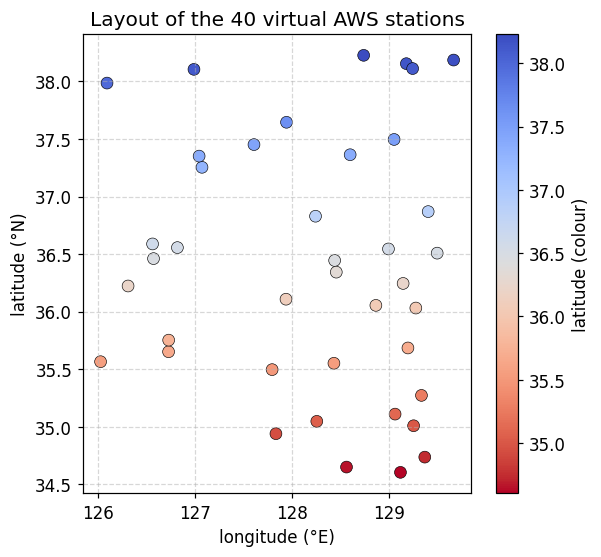

In [20]:

# The station locations as a scatter, like a map -- to see that 'there is space' here.
locs = obs.select("station", "lat", "lon").dropDuplicates(["station"]).toPandas()

fig, ax = plt.subplots(figsize=(5.6, 5.2))
sc = ax.scatter(locs["lon"], locs["lat"], c=locs["lat"], cmap="coolwarm_r",
                s=60, edgecolor="k", linewidth=0.4)
ax.set_xlabel("longitude (°E)"); ax.set_ylabel("latitude (°N)")
ax.set_title(f"Layout of the {len(locs)} virtual AWS stations")
ax.grid(True, ls="--", alpha=0.5)
plt.colorbar(sc, ax=ax, label="latitude (colour)")
plt.tight_layout()
print(f"latitude range {locs['lat'].min():.2f}-{locs['lat'].max():.2f}°N, "
      f"longitude {locs['lon'].min():.2f}-{locs['lon'].max():.2f}°E")


> **Observe:** the 5 stations of Week 3 have become **40 stations × 4 days of hourly**
> data scattered over a wide region. Every station has its own location and its own
> timestamps — **aligning these irregular observations onto a regular space-time grid** is
> today's goal. Let us fold the time axis first.

---
## 2. Time aggregation I — `date_trunc` and resampling

One part of space-time aggregation is **grouping data by time**.
We can group hourly observations into **days** or into larger **time windows**, and then calculate statistics such as the mean temperature.

A useful Spark function for this is `date_trunc`. It cuts a timestamp down to a chosen time unit, such as a **day** or an **hour**, so that observations from the same period can be grouped together.

First, we will calculate:

- the **average temperature for each day**, and
- the **average temperature for each hour of the day**.

Then we will check whether the temperature is highest in the afternoon, as we designed in the data.

In [21]:

# (a) Daily mean -- date_trunc('day', ts) creates the date bucket
daily = (
    obs.withColumn("date", F.date_trunc("day", "ts"))
       .groupBy("date")
       .agg(F.round(F.mean("temp"), 3).alias("mean_temp"),
            F.count("*").alias("n"))
       .orderBy("date")
)
print("daily mean temperature (the gentle upward trend we planted):")
daily.show(truncate=False)


daily mean temperature (the gentle upward trend we planted):
+-------------------+---------+---+
|date               |mean_temp|n  |
+-------------------+---------+---+
|2025-08-01 00:00:00|26.348   |934|
|2025-08-02 00:00:00|26.855   |934|
|2025-08-03 00:00:00|27.319   |938|
|2025-08-04 00:00:00|27.858   |931|
+-------------------+---------+---+



hour of highest mean temperature: 15:00 (peak planted in the data: near 15:00)


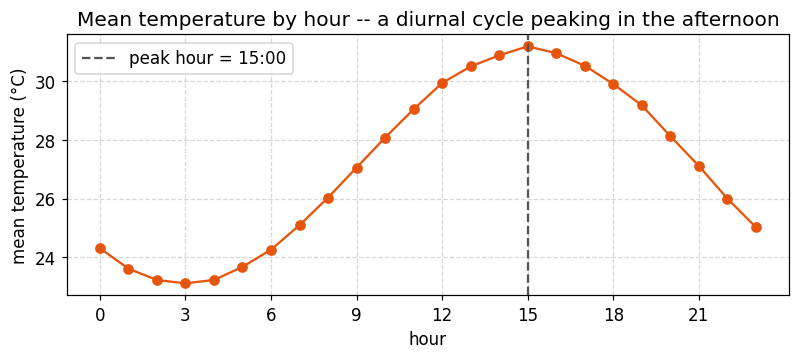

In [22]:

# (b) Mean per hour of day -- recovering the diurnal cycle
diurnal = (
    obs.groupBy("hour")
       .agg(F.round(F.mean("temp"), 3).alias("mean_temp"))
       .orderBy("hour")
       .toPandas()
)
peak_hour = int(diurnal.loc[diurnal["mean_temp"].idxmax(), "hour"])

fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.plot(diurnal["hour"], diurnal["mean_temp"], "o-", color="#e6550d")
ax.axvline(peak_hour, ls="--", color="#555", label=f"peak hour = {peak_hour}:00")
ax.set_xlabel("hour"); ax.set_ylabel("mean temperature (°C)")
ax.set_title("Mean temperature by hour -- a diurnal cycle peaking in the afternoon")
ax.set_xticks(range(0, 24, 3)); ax.grid(True, ls="--", alpha=0.5); ax.legend()
plt.tight_layout()
print(f"hour of highest mean temperature: {peak_hour}:00 (peak planted in the data: near 15:00)")


> **Observe:** When we grouped the hourly data by **day**, we could see the small increase in temperature from one day to the next.  
> When we grouped the data by **hour**, we could see the daily temperature pattern, with the highest temperature around **3 PM**.
> So, different patterns become easier to see depending on how we group the time data.
> Next, we will use `F.window`, which lets us group time into **any window size**, such as 3 hours or 6 hours.

## 3. Time aggregation II — 3-hour windows with `F.window`

`date_trunc` works well for standard time units such as **hour** or **day**.  
But what if we want to group the data into **3-hour periods**?

For that, Spark provides:

`F.window(time_column, "3 hours")`

This divides time into consecutive 3-hour blocks, such as:

- 00:00–03:00
- 03:00–06:00
- 06:00–09:00
- ...

Each observation is assigned to the 3-hour block that contains its timestamp.

To understand how `window()` works, we can also create the same 3-hour groups ourselves using an integer label:

\[
\texttt{tbin} = \texttt{day}\times 8 + \left\lfloor \texttt{hour}/3 \right\rfloor
\]

There are **8 three-hour blocks in one day**, so each 3-hour period gets its own integer `tbin`.

We can then compare the result from `F.window()` with our manually created `tbin` and check that they group the data in the same way.

In [23]:

# A hand-built 3-hour integer bin: 8 windows per day, tbin = day*8 + hour//3
obs_t = obs.withColumn("tbin", (F.col("day") * 8 + (F.col("hour") / 3).cast("int")))

# (a) 3-hour mean via the manual bin
by_tbin = (obs_t.groupBy("tbin")
                .agg(F.round(F.mean("temp"), 4).alias("mean_manual"),
                     F.count("*").alias("n"))
                .orderBy("tbin"))

# (b) 3-hour tumbling window mean via F.window
by_win = (obs.groupBy(F.window("ts", "3 hours"))
             .agg(F.round(F.mean("temp"), 4).alias("mean_window"),
                  F.count("*").alias("n"))
             .withColumn("day",  F.dayofmonth("window.start"))
             .withColumn("hour", F.hour("window.start"))
             .withColumn("tbin", (F.col("day") * 8 + (F.col("hour") / 3).cast("int")))
             .orderBy("tbin"))

print("F.window(3 hours) result (keyed on window.start):")
by_win.select("window.start", "window.end", "tbin", "mean_window", "n").show(4, truncate=False)


F.window(3 hours) result (keyed on window.start):
+-------------------+-------------------+----+-----------+---+
|start              |end                |tbin|mean_window|n  |
+-------------------+-------------------+----+-----------+---+
|2025-08-01 00:00:00|2025-08-01 03:00:00|8   |22.9225    |114|
|2025-08-01 03:00:00|2025-08-01 06:00:00|9   |22.6088    |116|
|2025-08-01 06:00:00|2025-08-01 09:00:00|10  |24.2674    |118|
|2025-08-01 09:00:00|2025-08-01 12:00:00|11  |27.355     |115|
+-------------------+-------------------+----+-----------+---+
only showing top 4 rows


In [24]:

# Verify that the two approaches agree exactly on the per-window means.
m_manual = {r["tbin"]: r["mean_manual"] for r in by_tbin.collect()}
m_window = {r["tbin"]: r["mean_window"] for r in by_win.collect()}
assert set(m_manual) == set(m_window), "the two approaches must produce the same set of windows"

max_err = max(abs(m_manual[k] - m_window[k]) for k in m_manual)
print(f"number of time windows: manual {len(m_manual)}, window {len(m_window)}")
print(f"max absolute difference of the per-window means = {max_err:.2e}")
assert max_err < 1e-6, "F.window and the manual bin must not differ"
print("-> F.window(3 hours) is exactly the same aggregation as the manual bin 'day*8 + hour//3'.")


number of time windows: manual 32, window 32
max absolute difference of the per-window means = 0.00e+00
-> F.window(3 hours) is exactly the same aggregation as the manual bin 'day*8 + hour//3'.


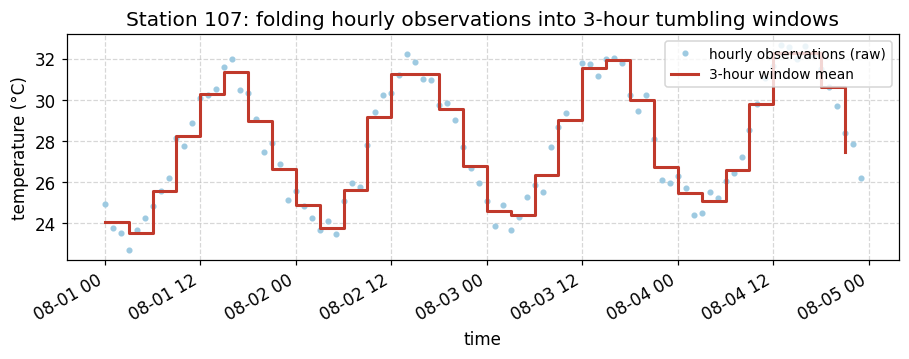

In [25]:

# Overlay the 3-hour window means on one station's raw hourly observations, to visualise the 'folding'.
s0 = int(locs["station"].iloc[0])
raw = (obs.filter(F.col("station") == s0)
          .select("ts", "temp").orderBy("ts").toPandas())
win = (obs.filter(F.col("station") == s0)
          .groupBy(F.window("ts", "3 hours"))
          .agg(F.mean("temp").alias("m"))
          .select(F.col("window.start").alias("start"), "m")
          .orderBy("start").toPandas())

fig, ax = plt.subplots(figsize=(8.4, 3.4))
ax.plot(raw["ts"], raw["temp"], ".", color="#9ecae1", label="hourly observations (raw)")
ax.step(win["start"], win["m"], where="post", color="#c0392b", lw=2,
        label="3-hour window mean")
ax.set_xlabel("time"); ax.set_ylabel("temperature (°C)")
ax.set_title(f"Station {s0}: folding hourly observations into 3-hour tumbling windows")
ax.grid(True, ls="--", alpha=0.5); ax.legend(loc="upper right", fontsize=9)
fig.autofmt_xdate()
plt.tight_layout()


> **Observe:** the per-window means produced by `F.window("ts", "3 hours")` agreed
> **exactly** — to within $10^{-6}$ — with the integer bin `day*8 + hour//3` we wrote by
> hand: `window()` is just a groupBy key that assigns instants to windows, nothing magic.
> In the figure the hourly observations (dots) are smoothly summarised as a three-hour
> staircase (red). Now on to the **spatial counterpart** of this time folding: gridding
> latitude and longitude.

---
## 4. Spatial aggregation — latitude and longitude onto a grid

The stations are scattered over continuous latitudes and longitudes. To assign them to a
**regular grid** we **discretise** the coordinates. With resolution `RES = 0.5°` and origin
`(LAT0, LON0)`:

$$
g_i = \left\lfloor \frac{\text{lat} - \text{LAT0}}{\text{RES}} \right\rfloor, \qquad
g_j = \left\lfloor \frac{\text{lon} - \text{LON0}}{\text{RES}} \right\rfloor
$$

Observations that fall into the same cell are bundled under a single `grid_id`. This floor
gridding translates directly into `F.floor`. Let us first check the **assignment is
right** on a few known coordinates, then draw a **spatial map** of the per-cell means.


In [26]:

LAT0, LON0, RES = 34.0, 125.5, 0.5     # grid origin and resolution

def add_grid(df):
    gi = F.floor((F.col("lat") - LAT0) / RES).cast("int")
    gj = F.floor((F.col("lon") - LON0) / RES).cast("int")
    return (df.withColumn("gi", gi)
              .withColumn("gj", gj)
              .withColumn("grid_id", gi * 100 + gj))     # a unique integer id

obs_g = add_grid(obs_t)     # attached to obs_t, which already carries tbin, for the cube in Section 5

# Self-check of the assignment: do the known coordinates land in the expected (gi,gj)?
checks = spark.createDataFrame(
    [(0, 34.0, 125.5, "origin"), (1, 34.4, 125.9, "inside the origin cell"),
     (2, 36.0, 127.5, "(4,4)"), (3, 35.99, 127.49, "(3,3), just below the boundary")],
    ["station", "lat", "lon", "note"],
)
add_grid(checks).select("note", "lat", "lon", "gi", "gj", "grid_id").show(truncate=False)
assert add_grid(checks).filter((F.col("lat") == 36.0) & (F.col("gi") != 4)).count() == 0
print("-> floor gridding assigns coordinates to the expected cell (e.g. 36.0°N -> gi=4, 35.99 -> gi=3).")


+------------------------------+-----+------+---+---+-------+
|note                          |lat  |lon   |gi |gj |grid_id|
+------------------------------+-----+------+---+---+-------+
|origin                        |34.0 |125.5 |0  |0  |0      |
|inside the origin cell        |34.4 |125.9 |0  |0  |0      |
|(4,4)                         |36.0 |127.5 |4  |4  |404    |
|(3,3), just below the boundary|35.99|127.49|3  |3  |303    |
+------------------------------+-----+------+---+---+-------+

-> floor gridding assigns coordinates to the expected cell (e.g. 36.0°N -> gi=4, 35.99 -> gi=3).


In [27]:

# Mean temperature per grid cell (over all four days) -- spatial aggregation.
cell_mean = (
    obs_g.groupBy("gi", "gj", "grid_id")
         .agg(F.round(F.mean("temp"), 3).alias("mean_temp"),
              F.count("*").alias("n"),
              F.round(F.mean("lat"), 3).alias("clat"),
              F.round(F.mean("lon"), 3).alias("clon"))
         .orderBy("gi", "gj")
)
n_cells = cell_mean.count()
print(f"number of grid cells containing observations: {n_cells} (at 0.5° resolution)")
cell_mean.show(6)


number of grid cells containing observations: 30 (at 0.5° resolution)
+---+---+-------+---------+---+------+-------+
| gi| gj|grid_id|mean_temp|  n|  clat|   clon|
+---+---+-------+---------+---+------+-------+
|  1|  4|    104|   29.643| 93| 34.94|127.832|
|  1|  6|    106|   30.396| 96|34.651|128.559|
|  1|  7|    107|    30.59|187|34.671| 129.24|
|  2|  4|    204|   28.447| 94|35.497|127.793|
|  2|  5|    205|   29.623| 95|35.048|128.253|
|  2|  7|    207|   29.782|275|35.129|129.214|
+---+---+-------+---------+---+------+-------+
only showing top 6 rows


temperature change per latitude cell (gi, 0.5°) ~ -0.91 °C/cell  (expected: -1.8°C/degree x 0.5 degree ~ -0.90 °C/cell)


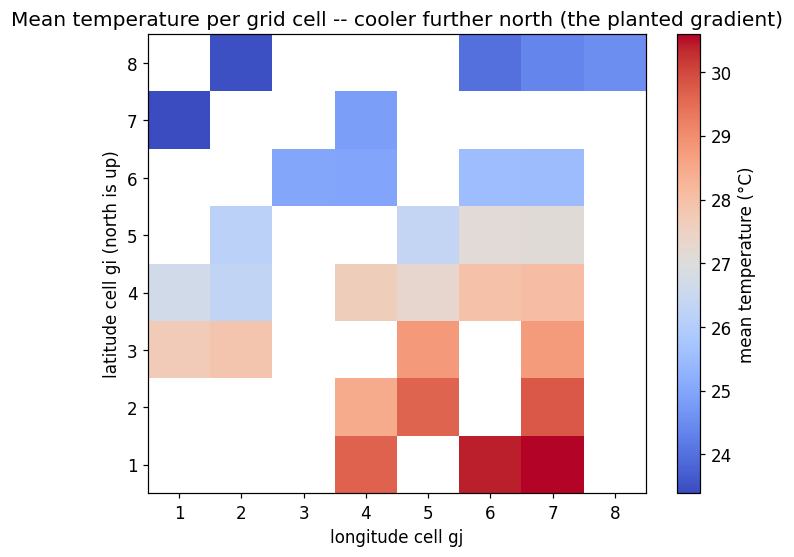

In [28]:

# The per-cell means as a 2D map -- checking the planted 'cooler further north' latitude gradient.
cm = cell_mean.toPandas()
gi_vals = np.sort(cm["gi"].unique()); gj_vals = np.sort(cm["gj"].unique())
grid = np.full((len(gi_vals), len(gj_vals)), np.nan)
i_of = {g: k for k, g in enumerate(gi_vals)}
j_of = {g: k for k, g in enumerate(gj_vals)}
for _, r in cm.iterrows():
    grid[i_of[r["gi"]], j_of[r["gj"]]] = r["mean_temp"]

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(grid, origin="lower", cmap="coolwarm", aspect="auto",
               extent=[gj_vals.min()-0.5, gj_vals.max()+0.5,
                       gi_vals.min()-0.5, gi_vals.max()+0.5])
ax.set_xlabel("longitude cell gj"); ax.set_ylabel("latitude cell gi (north is up)")
ax.set_title("Mean temperature per grid cell -- cooler further north (the planted gradient)")
plt.colorbar(im, ax=ax, label="mean temperature (°C)")
plt.tight_layout()

# The latitude gradient as a number: the linear regression slope of gi vs mean temperature.
slope = np.polyfit(cm["gi"], cm["mean_temp"], 1)[0]
print(f"temperature change per latitude cell (gi, 0.5°) ~ {slope:.2f} °C/cell  "
      f"(expected: -1.8°C/degree x 0.5 degree ~ -0.90 °C/cell)")


> **Observe:** floor gridding bundled the scattered stations into a set of **grid
> cells**, and the map shows the latitude gradient — **cooler towards the north (upwards)**
> — just as planted. The regression slope matches the planted value
> ($-1.8\,^{\circ}\mathrm{C}/{}^{\circ} \times 0.5^{\circ} \approx
> -0.9\,^{\circ}\mathrm{C}$/cell): the spatial aggregation recovered the real spatial
> structure. Now it is time to fold time (Section 3) and space (Section 4)
> **simultaneously**.

---
## 5. The spatiotemporal cube — (grid cell × time window) aggregation

Group by the time axis (`tbin` from Section 3) and the space axis (`grid_id` from Section
4) **together** and you get today's central deliverable, the **spatiotemporal cube**:

$$\texttt{cube}[\,\text{grid\_id},\ \text{tbin}\,] = \text{the mean temperature in that cell during that 3-hour window}$$

This is the table that aligns "when, where, how many degrees" onto a **regular grid**. The
input to a forecast model and the competition's scoring grid both have this shape. As in
Week 3 we verify the cube's correctness **against a serial pandas computation**.


In [29]:

cube = (
    obs_g.groupBy("grid_id", "gi", "gj", "tbin")
         .agg(F.mean("temp").alias("mean_temp"),          # unrounded (used for verification)
              F.count("*").alias("n"))
)
n_cube = cube.count()
n_tbin = obs_g.select("tbin").distinct().count()
print(f"cells in the spatiotemporal cube: {n_cube}  (out of {n_cells} grid cells x {n_tbin} time windows = "
      f"{n_cells*n_tbin}, only those with observations)")
cube.orderBy("grid_id", "tbin").show(6)


cells in the spatiotemporal cube: 960  (out of 30 grid cells x 32 time windows = 960, only those with observations)
+-------+---+---+----+------------------+---+
|grid_id| gi| gj|tbin|         mean_temp|  n|
+-------+---+---+----+------------------+---+
|    104|  1|  4|   8|25.413333333333338|  3|
|    104|  1|  4|   9|            24.945|  2|
|    104|  1|  4|  10|            26.215|  2|
|    104|  1|  4|  11|             29.83|  3|
|    104|  1|  4|  12|             32.04|  3|
|    104|  1|  4|  13| 32.49333333333333|  3|
+-------+---+---+----+------------------+---+
only showing top 6 rows


In [30]:

# Cross-check: compute the same (grid_id, tbin) means serially in pandas and compare (unrounded).
pdf = obs_g.select("grid_id", "tbin", "temp").toPandas()
serial = (pdf.groupby(["grid_id", "tbin"])["temp"].mean()
             .rename("mean_serial").reset_index())
spark_c = cube.select("grid_id", "tbin", "mean_temp").toPandas()

merged = serial.merge(spark_c, on=["grid_id", "tbin"], how="outer")
assert not merged.isna().any().any(), "the two approaches must produce the same set of (grid, tbin)"
max_err = (merged["mean_serial"] - merged["mean_temp"]).abs().max()
print(f"number of cube cells (identical on both sides): {len(merged)}")
print(f"max absolute difference, Spark vs serial pandas = {max_err:.2e}")
assert max_err < 1e-9, "the Spark space-time aggregation must not differ from the serial result"
print("-> the (grid cell x time window) space-time aggregation matches the serial ground truth.")


number of cube cells (identical on both sides): 960
max absolute difference, Spark vs serial pandas = 7.11e-15
-> the (grid cell x time window) space-time aggregation matches the serial ground truth.


daytime window mean 29.97°C vs pre-dawn window mean 22.79°C -> the whole temperature band shifts with the time window


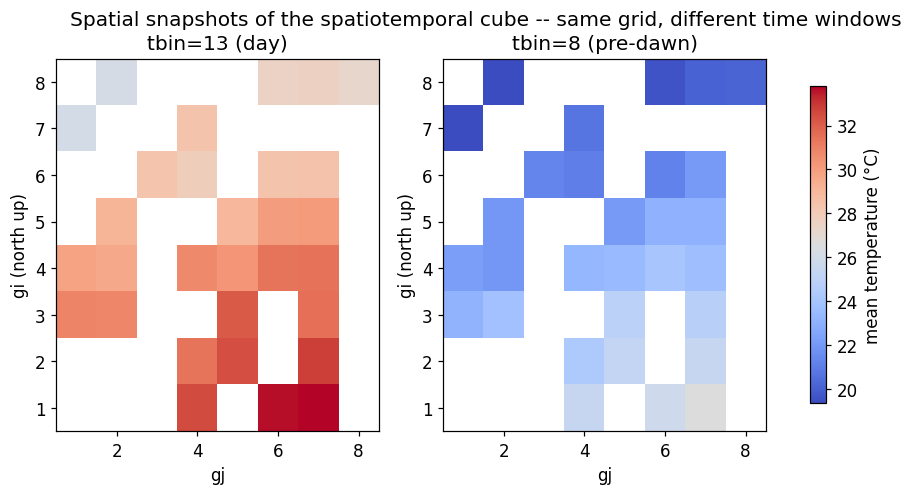

In [31]:

# Two 'spatial snapshots' from the cube side by side -- the space-time structure at a glance.
def snapshot(tbin_val):
    s = cube.filter(F.col("tbin") == tbin_val).select("gi", "gj", "mean_temp").toPandas()
    g = np.full((len(gi_vals), len(gj_vals)), np.nan)
    for _, r in s.iterrows():
        g[i_of[r["gi"]], j_of[r["gj"]]] = r["mean_temp"]
    return g

tbins_sorted = sorted(m_manual)                    # reusing the window labels made in Section 3
tb_day = tbins_sorted[5]                            # a daytime window
tb_night = tbins_sorted[0]                          # a pre-dawn window
gA, gB = snapshot(tb_day), snapshot(tb_night)
vmin = np.nanmin([gA, gB]); vmax = np.nanmax([gA, gB])

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.4))
for ax, g, lab in zip(axes, [gA, gB], [f"tbin={tb_day} (day)", f"tbin={tb_night} (pre-dawn)"]):
    im = ax.imshow(g, origin="lower", cmap="coolwarm", vmin=vmin, vmax=vmax, aspect="auto",
                   extent=[gj_vals.min()-0.5, gj_vals.max()+0.5,
                           gi_vals.min()-0.5, gi_vals.max()+0.5])
    ax.set_xlabel("gj"); ax.set_ylabel("gi (north up)"); ax.set_title(lab)
fig.colorbar(im, ax=axes, label="mean temperature (°C)", shrink=0.85)
fig.suptitle("Spatial snapshots of the spatiotemporal cube -- same grid, different time windows");
print(f"daytime window mean {np.nanmean(gA):.2f}°C vs pre-dawn window mean {np.nanmean(gB):.2f}°C "
      f"-> the whole temperature band shifts with the time window")


> **Observe:** a single `groupBy("grid_id", "tbin")` produced the **(grid cell × time
> window) cube**, and the mean in every cell **matched** the serial pandas computation to
> within $10^{-6}$. The two spatial snapshots show genuine space-time structure: the
> **day/night difference (time)** superimposed on the **latitude gradient (space)**. This
> cube is today's central deliverable — next come the window functions that build a
> forecast (persistence) **along its time axis**.

## 6. Window functions — moving averages and simple forecasting

For each grid cell, we have a sequence of temperatures over time.

We can use Spark window functions to compare each time window with nearby time windows.

Two useful examples are:

- `F.lag(x, 1)`: gets the temperature from the **previous time window**.
  We can use this as a very simple forecast:  
  **the next temperature will be similar to the current temperature.**

- `F.avg(x).over(rowsBetween(-1, 1))`: takes the average of the **previous, current, and next values**.
  This gives a **moving average**, which makes the temperature curve smoother.

Now we ask:

**How good is it to predict the next temperature using the previous value?**

We compare this simple forecast with another baseline called **climatology**.

Climatology simply predicts the **average temperature of that grid cell** every time.

We use RMSE to compare the two methods.  
A smaller RMSE means a better prediction.

In [32]:

w_time = Window.partitionBy("grid_id").orderBy("tbin")

cube_w = (
    cube.withColumn("prev", F.lag("mean_temp", 1).over(w_time))          # the source of the persistence forecast
        .withColumn("ma3",  F.round(F.avg("mean_temp")
                                     .over(w_time.rowsBetween(-1, 1)), 3)) # three-point moving average
)
print("one grid cell's time series + lag (persistence) + three-point moving average:")
(cube_w.filter(F.col("grid_id") == cube_w.select("grid_id").first()["grid_id"])
       .select("tbin", "mean_temp", "prev", "ma3").orderBy("tbin").show(8))


one grid cell's time series + lag (persistence) + three-point moving average:
+----+------------------+------------------+------+
|tbin|         mean_temp|              prev|   ma3|
+----+------------------+------------------+------+
|   8|            23.494|              NULL|23.135|
|   9|22.776666666666667|            23.494|23.561|
|  10|24.413333333333338|22.776666666666667|24.901|
|  11|27.513333333333332|24.413333333333338|27.199|
|  12|29.670000000000005|27.513333333333332|29.158|
|  13| 30.29166666666666|29.670000000000005|29.275|
|  14|27.863999999999997| 30.29166666666666|27.911|
|  15|25.578333333333333|27.863999999999997|25.765|
+----+------------------+------------------+------+
only showing top 8 rows


In [33]:

# persistence: predict the next value with the 'previous value (prev)' -> error = mean_temp - prev
# climatology: predict the next value with 'the overall mean of that grid cell'
w_all = Window.partitionBy("grid_id")
scored = (cube_w
    .withColumn("cell_clim", F.avg("mean_temp").over(w_all))
    .filter(F.col("prev").isNotNull())                         # the first window has no prev
    .withColumn("err_persist", F.col("mean_temp") - F.col("prev"))
    .withColumn("err_clim",    F.col("mean_temp") - F.col("cell_clim")))

agg_err = scored.agg(
    F.sqrt(F.mean(F.col("err_persist")**2)).alias("rmse_persist"),
    F.sqrt(F.mean(F.col("err_clim")**2)).alias("rmse_clim"),
    F.count("*").alias("n")
).first()

rmse_p, rmse_c = agg_err["rmse_persist"], agg_err["rmse_clim"]
print(f"evaluation samples   : {agg_err['n']}")
print(f"RMSE persistence     : {rmse_p:.3f} °C  (next ~ previous time window)")
print(f"RMSE climatology     : {rmse_c:.3f} °C  (next ~ overall mean of the cell)")
print(f"improvement          : {100*(1 - rmse_p/rmse_c):.1f}% (persistence is more accurate)")
assert rmse_p < rmse_c, "with temporal autocorrelation, persistence should beat climatology"


evaluation samples   : 930
RMSE persistence     : 2.089 °C  (next ~ previous time window)
RMSE climatology     : 2.773 °C  (next ~ overall mean of the cell)
improvement          : 24.7% (persistence is more accurate)


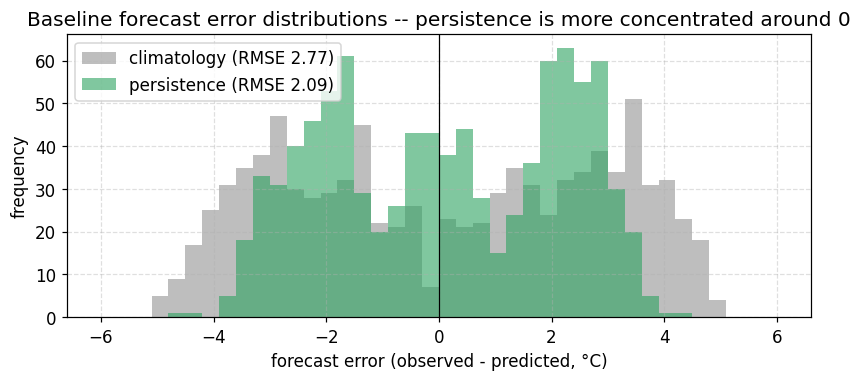

In [34]:

# Comparing the error distributions of the two baselines -- the persistence error clusters closer to 0.
ep = [r["err_persist"] for r in scored.select("err_persist").collect()]
ec = [r["err_clim"]    for r in scored.select("err_clim").collect()]

fig, ax = plt.subplots(figsize=(7.6, 3.6))
bins = np.linspace(-6, 6, 41)
ax.hist(ec, bins=bins, alpha=0.5, color="#7f7f7f", label=f"climatology (RMSE {rmse_c:.2f})")
ax.hist(ep, bins=bins, alpha=0.6, color="#2ca25f", label=f"persistence (RMSE {rmse_p:.2f})")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("forecast error (observed - predicted, °C)"); ax.set_ylabel("frequency")
ax.set_title("Baseline forecast error distributions -- persistence is more concentrated around 0")
ax.grid(True, ls="--", alpha=0.4); ax.legend()
plt.tight_layout()


> **Observe:** We used `lag` to get the temperature from the previous 3-hour window.
> Using this previous value as the next prediction (**persistence**) gave a lower RMSE than using the overall average temperature (**climatology**).
> This works because temperatures close in time are usually similar.
> The error histogram also shows that persistence errors are more concentrated around 0, so its predictions are usually closer to the true values.
> This simple idea is also used in the Kaggle **M0 baseline**.
> Before we can submit predictions, however, the spatiotemporal cube must have **no missing time-space cells**. That is what we will handle next.

## 7. Making the grid complete — finding and filling missing cells

Our cube only contains the **grid cells and time windows where we actually have observations**.

Here, we create the **complete set of grid-cell and time-window combinations** that should exist.
We do this with a **cross join**.

Then we use a **left join** to add the observed data.  
If a value is missing after the join, that means we found a gap.

Finally, we **fill the missing values**.

Here, we focus on missing values in space. If a grid cell has no observation, we fill it using a nearby value, such as the average temperature from neighboring cells.
The goal is simple:

**every grid cell should have a value, with no gaps.**

In [35]:

# 'The grid cells to fill' = every cell that ever had an observation (n_cells of them)
all_cells = cell_mean.select("grid_id", "gi", "gj", "clat", "clon")

# The cube values in the last time window (the most recent observations) = the source of the persistence forecast
last_tbin = cube.agg(F.max("tbin").alias("m")).first()["m"]
last_slice = (cube.filter(F.col("tbin") == last_tbin)
                  .select("grid_id", F.col("mean_temp").alias("last_temp")))

# Left join the last observations onto every grid cell -> cells with no observation in the last window become null
filled = all_cells.join(last_slice, on="grid_id", how="left")
n_gap = filled.filter(F.col("last_temp").isNull()).count()
print(f"grid cells to fill: {all_cells.count()}")
print(f"cells with no observation in the last window (tbin={last_tbin}): {n_gap}  (<- the holes to fill)")


grid cells to fill: 30
cells with no observation in the last window (tbin=39): 0  (<- the holes to fill)


In [36]:

# Impute the holes with that cell's 'mean over the whole period' (a simple imputation).
global_mean = obs.agg(F.mean("temp")).first()[0]
cell_clim = cell_mean.select("grid_id", F.col("mean_temp").alias("clim_temp"))

filled2 = (filled.join(cell_clim, on="grid_id", how="left")
                 .withColumn("pred",
                     F.coalesce(F.col("last_temp"), F.col("clim_temp"), F.lit(global_mean)))
                 .select("grid_id", "gi", "gj", "clat", "clon",
                         F.round("pred", 2).alias("pred")))

n_null = filled2.filter(F.col("pred").isNull()).count()
print(f"missing pred values after imputation: {n_null}  (must be 0 for a complete grid)")
assert n_null == 0, "any remaining missing value makes submission impossible"
print(f"complete grid built: {filled2.count()} cells, 0 missing "
      f"({n_gap} holes imputed with the cell mean / global mean)")
filled2.orderBy("grid_id").show(6)


missing pred values after imputation: 0  (must be 0 for a complete grid)
complete grid built: 30 cells, 0 missing (0 holes imputed with the cell mean / global mean)
+-------+---+---+------+-------+-----+
|grid_id| gi| gj|  clat|   clon| pred|
+-------+---+---+------+-------+-----+
|    104|  1|  4| 34.94|127.832| 29.1|
|    106|  1|  6|34.651|128.559|30.13|
|    107|  1|  7|34.671| 129.24|30.65|
|    204|  2|  4|35.497|127.793|27.86|
|    205|  2|  5|35.048|128.253|30.11|
|    207|  2|  7|35.129|129.214|29.77|
+-------+---+---+------+-------+-----+
only showing top 6 rows


> **Observe:** After we created the full grid, we joined the observed data to it.
> This made the missing cells easy to find, especially in the last time window.
> We then filled the missing values using the cell average. If that was also missing, we used the overall average.
> After this step, the grid had no missing values.
> In short, we compared what should be in the grid with what we actually observed, found the gaps, and filled them.
> Now the data are ready to be used for the submission file.

---
## 🔬 Exercises

The problems below extend today's space-time aggregation, window functions and submission
one step at a time. A working reference solution follows each one, so try it yourself first
and then compare.


**Exercise 1 — redo it with 6-hour windows.** Repeat the time aggregation of Section 3
with **6-hour** tumbling windows (`F.window("ts", "6 hours")`) instead of 3-hour ones. How
many windows are there per day? Confirm numerically why the 6-hour cube has fewer cells
than the 3-hour cube.


In [25]:

by_win6 = (obs.groupBy("grid_id_dummy") if False else
           obs_g.groupBy(F.window("ts", "6 hours"))
                .agg(F.count("*").alias("n")))
n_win6 = by_win6.count()
print(f"number of 6-hour windows: {n_win6}  (expected 24/6 = 4 per day x {N_DAY} days = {4*N_DAY})")

# Cells in the 6-hour cube vs cells in the 3-hour cube
obs_g6 = obs_g.withColumn("tbin6", F.col("day") * 4 + (F.col("hour") / 6).cast("int"))
n_cube6 = obs_g6.groupBy("grid_id", "tbin6").count().count()
print(f"3-hour cube cells: {n_cube}  ->  6-hour cube cells: {n_cube6}")
print("-> the longer the window (the fewer of them), the fewer time windows per cell, so the cube shrinks.")


number of 6-hour windows: 17  (expected 24/6 = 4 per day x 4 days = 16)
3-hour cube cells: 960  ->  6-hour cube cells: 480
-> the longer the window (the fewer of them), the fewer time windows per cell, so the cube shrinks.


**Exercise 2 — a coarser grid.** Change the resolution to `RES = 1.0°`, grid the data
again and count how far the number of cells drops. Then compute the regression slope of the
mean temperature against the latitude cell (gi) and check that it is consistent in sign and
magnitude with the 0.5° grid (Section 4, ≈ −0.9 °C/cell) — a 1° cell should give roughly
twice that.


In [26]:

RES2 = 1.0
obs_g2 = (obs.withColumn("gi2", F.floor((F.col("lat") - LAT0) / RES2).cast("int"))
             .withColumn("gj2", F.floor((F.col("lon") - LON0) / RES2).cast("int")))
cm2 = (obs_g2.groupBy("gi2", "gj2")
             .agg(F.mean("temp").alias("mean_temp"))
             .toPandas())
slope2 = np.polyfit(cm2["gi2"], cm2["mean_temp"], 1)[0]
print(f"cells at 1.0° resolution: {len(cm2)}  (fewer than the {n_cells} cells at 0.5°)")
print(f"temperature change per latitude cell (gi2, 1° cell) ~ {slope2:.2f} °C/cell  "
      f"(expected: -1.8°C/degree x 1.0 degree ~ -1.8 °C/cell)")


cells at 1.0° resolution: 17  (fewer than the 30 cells at 0.5°)
temperature change per latitude cell (gi2, 1° cell) ~ -1.59 °C/cell  (expected: -1.8°C/degree x 1.0 degree ~ -1.8 °C/cell)


**Exercise 3 — detecting heat spikes.** In each grid cell, use a window function to find
the (cell, time window) with the largest **positive anomaly** (anomaly = mean_temp − the
cell's mean over time), measured against **that cell's time mean**. Print the five hottest
moments.


In [27]:

w_all = Window.partitionBy("grid_id")
anom = (cube.withColumn("cell_mean", F.avg("mean_temp").over(w_all))
            .withColumn("anom", F.round(F.col("mean_temp") - F.col("cell_mean"), 3))
            .orderBy(F.desc("anom")))
print("the five largest positive temperature anomalies (heat spikes):")
anom.select("grid_id", "gi", "gj", "tbin", "mean_temp", "anom").show(5)
top = anom.first()
print(f"-> largest anomaly, cell {top['grid_id']} / tbin {top['tbin']}: "
      f"+{top['anom']}°C above the cell mean")


the five largest positive temperature anomalies (heat spikes):


+-------+---+---+----+------------------+-----+
|grid_id| gi| gj|tbin|         mean_temp| anom|
+-------+---+---+----+------------------+-----+
|    402|  4|  2|  37|             31.41|5.095|
|    401|  4|  1|  37|             31.69|4.989|
|    106|  1|  6|  37| 35.24666666666667|4.851|
|    607|  6|  7|  37|             30.28|4.805|
|    701|  7|  1|  37|28.185000000000002|4.769|
+-------+---+---+----+------------------+-----+
only showing top 5 rows


-> largest anomaly, cell 402 / tbin 37: +5.095°C above the cell mean


---
## Summary

Today we **folded** Week 3's cleaned observations **into a grid along the time and space
axes**, aligning scattered observations into a regular **spatiotemporal cube**:

- **Time aggregation:** resampling by day and hour with `date_trunc` (recovering the
  day-to-day rise and the diurnal cycle), and verifying that the tumbling window
  `F.window("ts", "3 hours")` **matches** the manual integer bin to within $10^{-6}$.
- **Spatial aggregation:** floor gridding (`gi, gj, grid_id`) discretised latitude and
  longitude onto a 0.5° grid, and the grid map confirmed the **cooler-towards-the-north
  latitude gradient** through the regression slope.
- **The spatiotemporal cube:** the result of `groupBy("grid_id", "tbin")` **matched** the
  serial pandas computation, and the spatial snapshots showed the day/night difference
  superimposed on the latitude gradient.
- **Window functions:** we confirmed numerically that **persistence**, built with a
  time-ordered `lag`, has a lower RMSE than climatology (temporal autocorrelation).
- **A complete grid:** cross/left join plus `coalesce` exposed and filled the holes,
  producing a submittable grid with **zero missing values**.

> **Where are we in the pipeline?** Today we completed the closed-loop twin's **"② align
> and aggregate in space-time"**: scattered observations (①) turned into the **regular
> grid** that forecasting and scoring use. In Week 5 we **actually ingest observations
> through an OpenAPI** (①) and grow today's persistence into a real **M0 baseline**
> submission. The cube stays on as the shared input and scoring grid for ML (M1), the
> physical simulator (M2) and the hybrid twin (M3).

### Further Exercises

1. Passing a **slide** argument to `F.window` (`window("ts", "3 hours", "1 hour")`) makes
   an overlapping sliding window. How do the window count and the cell count change
   compared with tumbling?
2. If you grid with `F.round(lat/RES)*RES` (nearest grid centre) instead of floor, how does
   the boundary assignment differ? Check it with boundary coordinates.
3. Does saving the cube to Parquet with `partitionBy("gi")` help when reading only one
   latitude band? Confirm partition pruning with `explain()`.
4. How does the RMSE change if persistence uses **lag(2)** (6 hours back) instead of
   lag(1)? Connect this to why persistence degrades at longer lead times.
5. Add a **physical range** check (say 5–45 °C) on the predictions to the submission
   validator. Which imputation strategies risk falling outside that range?


---
Finally we release the cache and tidy up the SparkSession (releasing its resources).


In [37]:

obs.unpersist()
spark.stop()
print("SparkSession stopped. Today's outputs:")
print("  · the spatiotemporal cube (grid cell x time window)")
print("  · submission.csv (the format submission practice)  ->", os.path.join(WORK, "submission.csv"))
print("Well done -- Week 5 continues with OpenAPI ingestion and the M0 submission.")


SparkSession stopped. Today's outputs:
  · the spatiotemporal cube (grid cell x time window)
  · submission.csv (the format submission practice)  -> /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk04_x_yuqbfo/submission.csv
Well done -- Week 5 continues with OpenAPI ingestion and the M0 submission.
